In [103]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from matplotlib import style
from Bio.Seq import Seq
from Bio import SeqIO
import RNA
import re

In [104]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [105]:
dataframe_list = []
sequences = []
k = 3

for sequence in SeqIO.parse("rna_families.fasta", "fasta"):
    temporary_sequences = {}
    fc = RNA.fold_compound(str(sequence.seq))
    (structure, mfe) = fc.mfe()
    length = len(sequence.seq)
    for x in range(len(sequence.seq) - (k-1)):
        codon = str(sequence.seq)[x : x+k]
        temporary_sequences[codon] = temporary_sequences.get(codon, 0) + 1
    sequences.append(temporary_sequences)      
    temporary_dict = {
        "Family" : sequence.description.split("Family: ")[1],
        "MFE_per_Base" : f"{(mfe / length):.2f}",
        "Paired_Fraction" : f"{((structure.count("(") + structure.count(")")) / length):.2f}",
        "Hairpin_Loops" : len(re.findall(r"\([.]{3,}\)", structure)),
        "GC_Composition" : f"{((sequence.count("G") + sequence.count("C")) / length):.2f}"
    }
    dataframe_list.append(temporary_dict)

df2 = pd.DataFrame(dataframe_list)
df3 = pd.DataFrame(sequences)
df3 = df3.astype("Int8")
df = pd.concat([df2, df3], axis = 1)
df = df.fillna(0)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [106]:
y = df.pop("Family").to_numpy()
X = df.to_numpy()
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)
model = RandomForestClassifier()
model.fit(train_X, train_y)
pred_y = model.predict(val_X)
print(classification_report(val_y, pred_y))

                     precision    recall  f1-score   support

            5S_rRNA       1.00      1.00      1.00         5
Hammerhead_Ribozyme       1.00      1.00      1.00         7
            SRP_RNA       1.00      1.00      1.00         5
           U2_snRNA       1.00      1.00      1.00         4
               tRNA       1.00      1.00      1.00         4

           accuracy                           1.00        25
          macro avg       1.00      1.00      1.00        25
       weighted avg       1.00      1.00      1.00        25



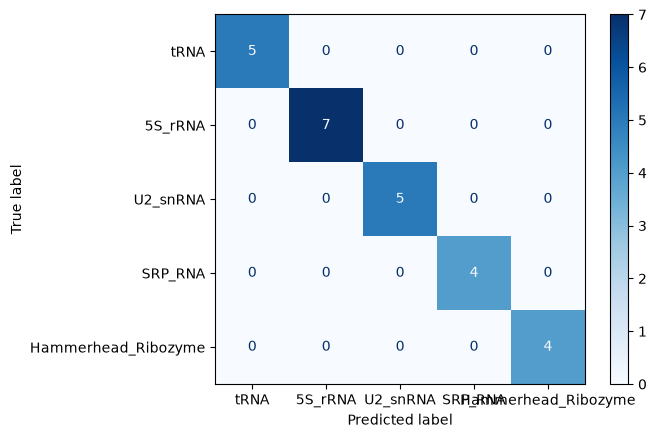

In [107]:
cm = confusion_matrix(val_y, pred_y)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['tRNA', '5S_rRNA', 'U2_snRNA', 'SRP_RNA', 'Hammerhead_Ribozyme'])
disp.plot(cmap=plt.cm.Blues)
plt.show()